# ***AI-Powered E-Commerce Fake Review Detection using pretrained DeBERTa Transformer Model Optimized with Monarch Butterfly Optimizer (MBO)***

**Description:**
*This is a deep learning based online e-commerce fake review classifier model using an optimized DeBERTa transformer architecture. Nature inspired swarm-intelligence based Monarch Butterfly algorithm is leveraged for optimizing the DeBERTa hyperparameters (Hyperparameter Tuning).*

*The model has been trained and evaluated on three real-world datasets - Amazon Reviews (amazon_reviews.csv - 21000 records), Hotel Reviews (ott-deceptive-opinion.csv - 1600 records), Product Reviews (fake reviews dataset.csv - 40,432 records). This notebook shows the model's implementation on the Hotel Reviews dataset*

**We are going to use the MBO implementation provided by Niapy library**

In [ ]:
!pip install niapy

**Import necessary libraries**

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from niapy.task import Task # for Monarch Butterfly Optimizer
from niapy.problems import Sphere
from niapy.problems import Problem

'from niapy.task import Task\nfrom niapy.problems import Sphere\nfrom niapy.problems import Problem'

**Hardware acceleration (GPU) for model training & evaluation**

In [ ]:
import torch

# If there's a GPU available...
if torch.cuda.is_available():

    # Tell PyTorch to use the GPU.
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: Tesla T4


**Load Dataset**

In [ ]:
# Load the dataset into a pandas dataframe.
df = pd.read_csv("/content/ott-deceptive-opinion.csv",encoding="ISO-8859-1")

# Report the number of sentences.
print('Number of training sentences: {:,}\n'.format(df.shape[0]))

# Display 10 random rows from the data.
df.sample(10)

Number of training sentences: 1,600



,deceptive,hotel,polarity,source,text
504,deceptive,homewood,positive,MTurk,I would first like to say how inviting the roo...
1481,deceptive,hilton,negative,MTurk,"When most people think Hilton, they think luxu..."
1031,truthful,hardrock,negative,Web,"This morning, I checked out and left behind on..."
1237,deceptive,omni,negative,MTurk,"Last week, I booked a 'Deluxe Suite' at the Om..."
1017,truthful,ambassador,negative,Web,"The Good - excellent location, neighborhood is..."
694,deceptive,hilton,positive,MTurk,Excellent hotel in the heart of Chicago. The r...
60,truthful,omni,positive,TripAdvisor,Great hotel in heart of Chicago for business o...
933,truthful,homewood,negative,Web,After reading good reviews about I booked a 5 ...
1229,deceptive,omni,negative,MTurk,I have no idea why this is considered a four s...
197,truthful,talbott,positive,TripAdvisor,I have just returned from a lovely shopping tr...


**We just need the review texts and corresponding labels**

In [ ]:
text=df['text']
label = df['deceptive']

In [ ]:
print (text[1])

Triple A rate with upgrade to view room was less than $200 which also included breakfast vouchers. Had a great view of river, lake, Wrigley Bldg. & Tribune Bldg. Most major restaurants, Shopping, Sightseeing attractions within walking distance. Large room with a very comfortable bed. 



**Encode the labels: 1 - true reviews, 0 - fake reviews**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
yt = le.fit_transform(label)
print(label)
print(yt)

0        truthful
1        truthful
2        truthful
3        truthful
4        truthful
          ...    
1595    deceptive
1596    deceptive
1597    deceptive
1598    deceptive
1599    deceptive
Name: deceptive, Length: 1600, dtype: object
[1 1 1 ... 0 0 0]


# **NLP-based Exploratory Data Analysis and Preprocessing**

**Import necessary libraries**

In [ ]:
import re
import contractions
from collections import Counter

# Copy for preprocessing
cleaned_text = text.copy()

# Counters for reporting
removal_counts = Counter()

**Check for missing values**

In [ ]:
print(df.isnull().sum())

deceptive    0
hotel        0
polarity     0
source       0
text         0
dtype: int64


**Remove URLs, hashtags, @ mentions, and email IDs**

In [ ]:
def remove_noise(text):
    urls = len(re.findall(r'https?://\S+|www\.\S+', text))
    hashtags = len(re.findall(r'#\w+', text))
    mentions = len(re.findall(r'@\w+', text))
    emails = len(re.findall(r'\S+@\S+', text))

    # Remove them
    text = re.sub(r'https?://\S+|www\.\S+', '', text)       # URLs
    text = re.sub(r'#\w+', '', text)                        # Hashtags
    text = re.sub(r'@\w+', '', text)                        # Mentions
    text = re.sub(r'\S+@\S+', '', text)                     # Email IDs

    # Update global counters
    removal_counts['urls'] += urls
    removal_counts['hashtags'] += hashtags
    removal_counts['mentions'] += mentions
    removal_counts['emails'] += emails

    return text

cleaned_text = cleaned_text.apply(remove_noise)

print(f"Removed {removal_counts['urls']} URLs")
print(f"Removed {removal_counts['hashtags']} # tags")
print(f"Removed {removal_counts['mentions']} @ mentions")
print(f"Removed {removal_counts['emails']} email IDs")

Removed 27 URLs
Removed 15 # tags
Removed 6 @ mentions
Removed 5 email IDs



**Remove extra whitespaces**

In [ ]:
def remove_extra_whitespace(text):
    before = len(re.findall(r'\s{2,}', text))
    text = re.sub(r'\s{2,}', ' ', text).strip()
    removal_counts['extra_spaces'] += before
    return text

cleaned_text = cleaned_text.apply(remove_extra_whitespace)
print(f"Removed {removal_counts['extra_spaces']} extra whitespaces")

Removed 150 extra whitespaces



**Remove extra punctuations (e.g., great!!! -> great!, why??? -> why?)**

In [ ]:
def remove_extra_punctuations(text):
    # Count repeated punctuation like "!!!" or "???" or "...."
    before = len(re.findall(r'([!?.,])\1{1,}', text))
    text = re.sub(r'([!?.,])\1{1,}', r'\1', text)
    removal_counts['extra_punct'] += before
    return text

cleaned_text = cleaned_text.apply(remove_extra_punctuations)
print(f"Removed {removal_counts['extra_punct']} extra punctuations")

Removed 76 extra punctuations



**Expand contractions (e.g. don't -> do not, can't -> cannot)**

In [ ]:
def expand_contractions(text):
    # Count roughly how many contractions are found
    before = len(re.findall(r"\b(can't|won't|n't|'re|'s|'d|'ll|'ve|'m)\b", text))
    expanded = contractions.fix(text)
    if before > 0:
        removal_counts['contractions'] += before
    return expanded

cleaned_text = cleaned_text.apply(expand_contractions)
print(f"Expanded {removal_counts['contractions']} contractions")

Expanded 80 contractions



**Normalize elongated words (e.g., 'soooo' -> 'soo')**

In [ ]:
def normalize_elongated_words(text):
    # Count occurrences of elongated words like 'loooove'
    before = len(re.findall(r'(\w)\1{2,}', text))
    text = re.sub(r'(\w)\1{2,}', r'\1\1', text)
    removal_counts['elongated'] += before
    return text

cleaned_text = cleaned_text.apply(normalize_elongated_words)
print(f"Normalized {removal_counts['elongated']} elongated words")

Normalized 54 elongated words



In [ ]:
# Assign cleaned text back
df['clean_text'] = cleaned_text

# Display a few cleaned samples
print("Sample cleaned texts:\n")
print(df[['text', 'clean_text']].sample(5).to_string(index=False))


Sample cleaned texts:

text                                               clean_text
This hotel was soooo good!!! #amazing              This hotel was soo good!
I can't believe they charged me twice!             I cannot believe they charged me twice!
Email me at christina123@gmail.com for refund      Email me for refund
Service was BADDDDD!!!                             Service was BADD!
@staff were really helpful though.                 were really helpful though.


In [ ]:
text = cleaned_text # for model training/testing

**Tokenization**

In [ ]:
#import transformers
from transformers import DebertaTokenizer

# Load the DeBERTa tokenizer.
print('Loading DebertaTokenizer tokenizer...')
tokenizer = DebertaTokenizer.from_pretrained('microsoft/deberta-base', do_lower_case=True)


Loading BERT tokenizer...


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

In [ ]:
# Print the original sentence.
print(' Original: ', text[0])

 Original:  We stayed for a one night getaway with family on a thursday. Triple AAA rate of 173 was a steal. 7th floor room complete with 44in plasma TV bose stereo, voss and evian water, and gorgeous bathroom(no tub but was fine for us) Concierge was very helpful. You cannot beat this location... Only flaw was breakfast was pricey and service was very very slow(2hours for four kids and four adults on a friday morning) even though there were only two other tables in the restaurant. Food was very good so it was worth the wait. I would return in a heartbeat. A gem in chicago... 



In [ ]:
print('Tokenized: ', tokenizer.tokenize(text[0]))

Tokenized:  ['We', 'Ġstayed', 'Ġfor', 'Ġa', 'Ġone', 'Ġnight', 'Ġget', 'away', 'Ġwith', 'Ġfamily', 'Ġon', 'Ġa', 'Ġth', 'ursday', '.', 'ĠTriple', 'ĠAAA', 'Ġrate', 'Ġof', 'Ġ173', 'Ġwas', 'Ġa', 'Ġsteal', '.', 'Ġ7', 'th', 'Ġfloor', 'Ġroom', 'Ġcomplete', 'Ġwith', 'Ġ44', 'in', 'Ġplasma', 'ĠTV', 'Ġb', 'ose', 'Ġstereo', ',', 'Ġv', 'oss', 'Ġand', 'Ġev', 'ian', 'Ġwater', ',', 'Ġand', 'Ġgorgeous', 'Ġbathroom', '(', 'no', 'Ġtub', 'Ġbut', 'Ġwas', 'Ġfine', 'Ġfor', 'Ġus', ')', 'ĠConc', 'ier', 'ge', 'Ġwas', 'Ġvery', 'Ġhelpful', '.', 'ĠYou', 'Ġcannot', 'Ġbeat', 'Ġthis', 'Ġlocation', '...', 'ĠOnly', 'Ġflaw', 'Ġwas', 'Ġbreakfast', 'Ġwas', 'Ġpricey', 'Ġand', 'Ġservice', 'Ġwas', 'Ġvery', 'Ġvery', 'Ġslow', '(', '2', 'hours', 'Ġfor', 'Ġfour', 'Ġkids', 'Ġand', 'Ġfour', 'Ġadults', 'Ġon', 'Ġa', 'Ġfr', 'iday', 'Ġmorning', ')', 'Ġeven', 'Ġthough', 'Ġthere', 'Ġwere', 'Ġonly', 'Ġtwo', 'Ġother', 'Ġtables', 'Ġin', 'Ġthe', 'Ġrestaurant', '.', 'ĠFood', 'Ġwas', 'Ġvery', 'Ġgood', 'Ġso', 'Ġit', 'Ġwas', 'Ġworth', 'Ġthe', 'Ġ

In [ ]:
print('Token IDs: ', tokenizer.convert_tokens_to_ids(tokenizer.tokenize(text[0])))

Token IDs:  [170, 4711, 13, 10, 65, 363, 120, 4384, 19, 284, 15, 10, 3553, 46806, 4, 8424, 17147, 731, 9, 30011, 21, 10, 8052, 4, 262, 212, 1929, 929, 1498, 19, 3550, 179, 29051, 1012, 741, 3876, 31436, 6, 748, 5434, 8, 7630, 811, 514, 6, 8, 12058, 8080, 1640, 2362, 17465, 53, 21, 2051, 13, 201, 43, 21657, 906, 1899, 21, 182, 7163, 4, 370, 1395, 1451, 42, 2259, 734, 4041, 22892, 21, 7080, 21, 26428, 8, 544, 21, 182, 182, 2635, 1640, 176, 21719, 13, 237, 1159, 8, 237, 3362, 15, 10, 6664, 21746, 662, 43, 190, 600, 89, 58, 129, 80, 97, 9248, 11, 5, 2391, 4, 3652, 21, 182, 205, 98, 24, 21, 966, 5, 2067, 4, 38, 74, 671, 11, 10, 28288, 4, 83, 15538, 11, 1855, 42938, 734, 1437, 50118]


1.   **Add special tokens [CLS] for classification and [SEP] for marking sentence boundaries**
2.   **Tokenize all the sentences**
3.   **Convert tokens to their respective token IDs based on the model's (DeBERTa) vocabulary**

In [ ]:
# Tokenize all of the sentences and map the tokens to their IDs.
input_ids = []

# For every sentence...
for sent in text:
    # `encode` will:
    #   (1) Tokenize the sentence.
    #   (2) Prepend the `[CLS]` token to the start.
    #   (3) Append the `[SEP]` token to the end.
    #   (4) Map tokens to their IDs.
    encoded_sent = tokenizer.encode(
                        sent[:512],                      # Sentence to encode.
                        add_special_tokens = True, # Add '[CLS]' and '[SEP]'

                        # This function also supports truncation and conversion
                        # to pytorch tensors, but we need to do padding, so we
                        # can't use these features :( .
                        #max_length = 128,          # Truncate all sentences.
                        #return_tensors = 'pt',     # Return pytorch tensors.
                   )

    # Add the encoded sentence to the list.
    input_ids.append(encoded_sent)


In [ ]:
# Print sentence 0, now as a list of IDs.
print('Original: ', text[1])
print('Token IDs:', input_ids[1])

Original:  Triple A rate with upgrade to view room was less than $200 which also included breakfast vouchers. Had a great view of river, lake, Wrigley Bldg. & Tribune Bldg. Most major restaurants, Shopping, Sightseeing attractions within walking distance. Large room with a very comfortable bed. 

Token IDs: [1, 35587, 8293, 83, 731, 19, 6662, 7, 1217, 929, 21, 540, 87, 68, 2619, 61, 67, 1165, 7080, 25137, 4, 7301, 10, 372, 1217, 9, 4908, 6, 8037, 6, 305, 7638, 607, 163, 4779, 571, 4, 359, 7990, 163, 4779, 571, 4, 1993, 538, 4329, 6, 21261, 6, 31833, 33471, 16530, 624, 3051, 4472, 4, 13769, 929, 19, 10, 182, 3473, 3267, 4, 1437, 50118, 2]


In [ ]:
print('Max sentence length: ', max([len(sen) for sen in input_ids]))

Max sentence length:  143


**Padding sentences with [PAD] tokens (token ID = 0)**

In [ ]:
# We'll borrow the `pad_sequences` utility function to do this.
from keras.preprocessing.sequence import pad_sequences

# Set the maximum sequence length.
# I've chosen 256.
MAX_LEN = 256

print('\nPadding/truncating all sentences to %d values...' % MAX_LEN)

print('\nPadding token: "{:}", ID: {:}'.format(tokenizer.pad_token, tokenizer.pad_token_id))

# Pad our input tokens with value 0.
# "post" indicates that we want to pad and truncate at the end of the sequence,
# as opposed to the beginning.
input_ids = pad_sequences(input_ids, maxlen=MAX_LEN, dtype="long",
                          value=0, truncating="post", padding="post")

print('\nDone.')


Padding/truncating all sentences to 256 values...

Padding token: "[PAD]", ID: 0

Done.


**Creating Attention Masks**

In [ ]:
# Create attention masks
attention_masks = []

# For each sentence...
for sent in input_ids:

    # Create the attention mask.
    #   - If a token ID is 0, then it's padding, set the mask to 0.
    #   - If a token ID is > 0, then it's a real token, set the mask to 1.
    att_mask = [int(token_id > 0) for token_id in sent]

    # Store the attention mask for this sentence.
    attention_masks.append(att_mask)

**Train-Test Split (80-20)**

In [ ]:
# Use train_test_split to split our data into train and validation sets for
# training

from sklearn.model_selection import train_test_split

# Use 80% for training and 20% for validation.
train_inputs, validation_inputs, train_labels, validation_labels = train_test_split(input_ids, yt,
                                                            random_state=2018, test_size=0.2)
# Do the same for the masks.
train_masks, validation_masks, _, _ = train_test_split(attention_masks, yt,
                                             random_state=2018, test_size=0.2)

**Convert Data to PyTorch Tensors**

In [ ]:
# Convert all inputs and labels into torch tensors, the required datatype
# for our model.
train_inputs = torch.tensor(train_inputs)
validation_inputs = torch.tensor(validation_inputs)

train_labels = torch.tensor(train_labels)
validation_labels = torch.tensor(validation_labels)

train_masks = torch.tensor(train_masks)
validation_masks = torch.tensor(validation_masks)

**Dividing into batches (Batch size = 16)**

In [ ]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

# The DataLoader needs to know our batch size for training, so we specify it
# here.
# For fine-tuning BERT on a specific task, the authors recommend a batch size of
# 16 or 32.

batch_size = 16

# Create the DataLoader for our training set.
train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

# Create the DataLoader for our validation set.
validation_data = TensorDataset(validation_inputs, validation_masks, validation_labels)
validation_sampler = SequentialSampler(validation_data)
validation_dataloader = DataLoader(validation_data, sampler=validation_sampler, batch_size=batch_size)

In [ ]:
torch.cuda.empty_cache()

In [ ]:
from transformers import get_linear_schedule_with_warmup


# **MBO Optimization for Hyperparameter Tuning (finding the best possible hyperparameters combination for DeBERTa model using MBO)**

In [ ]:
import torch
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset
from transformers import get_linear_schedule_with_warmup, AutoModelForSequenceClassification
from torch.optim import AdamW
from niapy.task import Task
from niapy.problems import Problem
from niapy.algorithms.basic import MonarchButterflyOptimization # Our Optimizer for Hyperparameter Tuning of DeBERTa

# Define problem for hyperparameter optimization
class HyperparameterOptimization(Problem):
    def __init__(self):
        # Dimension 8 (8 Hyperparams): learning_rate, weight_decay, dropout_rate, attention_dropout, warmup_ratio, adam_epsilon, max_grad_norm, hidden_dropout
        super().__init__(dimension=8, lower=[1e-6, 0.0, 0.1, 0.1, 0.0, 1e-8, 0.5, 0.1], upper=[5e-4, 0.1, 0.5, 0.5, 0.2, 1e-6, 5.0, 0.5], type='float')

    def _evaluate(self, x):
        learning_rate = x[0]
        weight_decay = x[1]
        dropout_rate = x[2]
        attention_dropout = x[3]
        warmup_ratio = x[4]
        adam_epsilon = x[5]
        max_grad_norm = x[6]
        hidden_dropout = x[7]

        print(f"\nEvaluating hyperparameters: lr={learning_rate:.2e}, wd={weight_decay:.6f}, " +
              f"do={dropout_rate:.2f}, ad={attention_dropout:.2f}, wr={warmup_ratio:.2f}, " +
              f"ae={adam_epsilon:.2e}, mgn={max_grad_norm:.2f}, hdo={hidden_dropout:.2f}")

        # Load the DeBERTaV3 model
        model = AutoModelForSequenceClassification.from_pretrained(
            "microsoft/deberta-base",
            num_labels=2,
            output_attentions=False,
            output_hidden_states=False,
        )
        model.config.hidden_dropout_prob = hidden_dropout
        model.config.attention_probs_dropout_prob = attention_dropout
        model.cuda()

        # Optimizer and scheduler
        optimizer = AdamW(model.parameters(), lr=learning_rate, eps=adam_epsilon, weight_decay=weight_decay)
        total_steps = len(train_dataloader) * 20  # 20 epochs for evaluation
        warmup_steps = int(warmup_ratio * total_steps)
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

        # Training
        for epoch in range(20):
          model.train()
          total_loss = 0
          for batch in train_dataloader:
              b_input_ids = batch[0].to(device)
              b_input_mask = batch[1].to(device)
              b_labels = batch[2].to(device)
              model.zero_grad()
              outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
              loss = outputs.loss
              total_loss += loss.item()
              loss.backward()
              torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
              optimizer.step()
              scheduler.step()

          avg_train_loss = total_loss / len(train_dataloader)

          # We want to minimize loss, so return it directly
          return avg_train_loss

# Run GWO for hyperparameter optimization
task = Task(problem=HyperparameterOptimization(), max_iters=20)
algo = MonarchButterflyOptimization(
    population_size=15,
    seed=42  # For reproducibility
)

print("Starting Monarch Butterfly Optimization for hyperparameter tuning...")
best_solution, best_fitness = algo.run(task)

param_names = [
    "learning_rate", "weight_decay", "dropout_rate", "attention_dropout",
    "warmup_ratio", "adam_epsilon", "max_grad_norm", "hidden_dropout"
]

print("\nOptimization complete!")
print(f"Best Loss: {best_fitness:.4f}")
print("Best hyperparameters:")
for i, param in enumerate(param_names):
    print(f"  {param}: {best_solution[i]}")

Starting Monarch Butterfly Optimization for hyperparameter tuning...

Evaluating hyperparameters: lr=3.20e-04, wd=0.002501, do=0.21, ad=0.19, wr=0.15, ae=6.80e-07, mgn=4.51, hdo=0.13

Evaluating hyperparameters: lr=1.10e-04, wd=0.050536, do=0.11, ad=0.18, wr=0.13, ae=5.49e-07, mgn=1.49, hdo=0.34

Evaluating hyperparameters: lr=4.03e-04, wd=0.069814, do=0.24, ad=0.16, wr=0.19, ae=3.43e-07, mgn=0.92, hdo=0.14

Evaluating hyperparameters: lr=4.04e-04, wd=0.072973, do=0.31, ad=0.49, wr=0.08, ae=5.57e-07, mgn=4.23, hdo=0.35

Evaluating hyperparameters: lr=3.53e-04, wd=0.004582, do=0.19, ad=0.22, wr=0.02, ae=2.40e-07, mgn=0.95, hdo=0.21

Evaluating hyperparameters: lr=1.86e-04, wd=0.020951, do=0.21, ad=0.47, wr=0.13, ae=6.13e-07, mgn=1.27, hdo=0.39

Evaluating hyperparameters: lr=4.95e-04, wd=0.064000, do=0.32, ad=0.37, wr=0.17, ae=7.78e-07, mgn=1.53, hdo=0.11

Evaluating hyperparameters: lr=1.06e-04, wd=0.094291, do=0.45, ad=0.23, wr=0.13, ae=4.02e-07, mgn=4.62, hdo=0.28

Evaluating hyperpa

In [ ]:
best_params = dict(zip(param_names, best_solution))

**Load the pretrained model and initialise with best hyperparams given by MBO**

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
        "microsoft/deberta-base",
        num_labels=2,
        output_attentions=False,
        output_hidden_states=False,
    )

model.config.hidden_dropout_prob = best_params["hidden_dropout"]
model.config.attention_probs_dropout_prob = best_params["attention_dropout"]


# Tell pytorch to run this model on the GPU.
model.to(device)

pytorch_model.bin:   0%|          | 0.00/559M [00:00<?, ?B/s]

Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DebertaForSequenceClassification(
  (deberta): DebertaModel(
    (embeddings): DebertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=0)
      (LayerNorm): DebertaLayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaLayer(
          (attention): DebertaAttention(
            (self): DisentangledSelfAttention(
              (in_proj): Linear(in_features=768, out_features=2304, bias=False)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (pos_proj): Linear(in_features=768, out_features=768, bias=False)
              (pos_q_proj): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): DebertaLayerNorm()
              (dropout): Dropout(p=0

In [ ]:
!nvidia-smi

Sun Dec 22 07:06:53 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   42C    P0              25W /  70W |    693MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
# Get all of the model's parameters as a list of tuples.
params = list(model.named_parameters())

print('The BERT model has {:} different named parameters.\n'.format(len(params)))

print('==== Embedding Layer ====\n')

for p in params[0:5]:
    print("{:<55} {:>12}".format(p[0], str(tuple(p[1].size()))))

print('\n==== First Transformer ====\n')

for p in params[5:21]:
    print("{:<55} {:>12}".format(p[0], str(tuple(p[1].size()))))

print('\n==== Output Layer ====\n')

for p in params[-4:]:
    print("{:<55} {:>12}".format(p[0], str(tuple(p[1].size()))))



The BERT model has 200 different named parameters.

==== Embedding Layer ====

deberta.embeddings.word_embeddings.weight               (50265, 768)
deberta.embeddings.LayerNorm.weight                           (768,)
deberta.embeddings.LayerNorm.bias                             (768,)
deberta.encoder.layer.0.attention.self.q_bias                 (768,)
deberta.encoder.layer.0.attention.self.v_bias                 (768,)

==== First Transformer ====

deberta.encoder.layer.0.attention.self.in_proj.weight    (2304, 768)
deberta.encoder.layer.0.attention.self.pos_proj.weight    (768, 768)
deberta.encoder.layer.0.attention.self.pos_q_proj.weight   (768, 768)
deberta.encoder.layer.0.attention.self.pos_q_proj.bias        (768,)
deberta.encoder.layer.0.attention.output.dense.weight     (768, 768)
deberta.encoder.layer.0.attention.output.dense.bias           (768,)
deberta.encoder.layer.0.attention.output.LayerNorm.weight       (768,)
deberta.encoder.layer.0.attention.output.LayerNorm.bias     

**Initialize Gradient Descent Optimizer (AdamW) with the best hyperparams given by MBO**

In [ ]:
optimizer = AdamW(
        model.parameters(),
        lr=best_params["learning_rate"],
        eps=best_params["adam_epsilon"],
        weight_decay=best_params["weight_decay"]
    )

In [ ]:
# Number of training epochs
epochs = 50

# Total number of training steps is number of batches * number of epochs.
total_steps = len(train_dataloader) * epochs

# Create the learning rate scheduler.
total_steps = len(train_dataloader) * epochs
warmup_steps = int(best_params["warmup_ratio"] * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

scheduler

In [ ]:
import numpy as np

# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

In [ ]:
import time
import datetime

def format_time(elapsed):
    '''
    Takes a time in seconds and returns a string hh:mm:ss
    '''
    # Round to the nearest second.
    elapsed_rounded = int(round((elapsed)))

    # Format as hh:mm:ss
    return str(datetime.timedelta(seconds=elapsed_rounded))

# **Model Fine-tuning and Evaluation with the best hyperparameter configuration**

In [ ]:

import torch.nn as nn
import random
import numpy as np
import torch
import time
from transformers import AdamW, get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score

# Set the seed value all over the place to make this reproducible.
seed_val = 42

random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

# Store the average loss and accuracy after each epoch for plotting
train_loss_values = []
train_accuracy_values = []
validation_loss_values = []
validation_accuracy_values = []

# Track total training time
total_training_time = time.time()

# For each epoch...
for epoch_i in range(0, 50):

    # ========================================
    #               Training
    # ========================================

    # Perform one full pass over the training set.

    print("")
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
    print('Training...')

    # Measure how long the training epoch takes.
    t0 = time.time()

    # Reset the total loss for this epoch.
    total_loss = 0
    total_accuracy = 0

    # Put the model into training mode.
    model.train()

    # For each batch of training data...
    for step, batch in enumerate(train_dataloader):

        # Unpack this training batch from our dataloader.
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        # Clear gradients before each instance
        model.zero_grad()

        # Forward pass
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss
        logits = outputs.logits

        # Accumulate the training loss
        total_loss += loss.item()

        # Backward pass
        loss.backward()

        # Clip the norm of the gradients to prevent explosion
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update parameters
        optimizer.step()
        scheduler.step()

        # Track the accuracy
        preds = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()
        total_accuracy += accuracy_score(np.argmax(preds, axis=1), label_ids)

    # Calculate the average loss and accuracy over the training data.
    avg_train_loss = total_loss / len(train_dataloader)
    avg_train_accuracy = total_accuracy / len(train_dataloader)

    # Store the loss and accuracy values for plotting
    train_loss_values.append(avg_train_loss)
    train_accuracy_values.append(avg_train_accuracy)

    print("  Average training loss: {0:.4f}".format(avg_train_loss))
    print("  Average training accuracy: {0:.4f}".format(avg_train_accuracy))
    print("  Training epoch took: {:}".format(format_time(time.time() - t0)))

    # ========================================
    #               Validation
    # ========================================
    # After the completion of each training epoch, measure our performance on
    # our validation set.

    print("")
    print("Running Validation...")

    t0 = time.time()

    # Put the model in evaluation mode--the dropout layers behave differently
    # during evaluation.
    model.eval()

    # Tracking variables
    eval_loss, eval_accuracy = 0, 0
    nb_eval_steps, nb_eval_examples = 0, 0

    # Evaluate data for one epoch
    for batch in validation_dataloader:
      # Add batch to GPU
      batch = tuple(t.to(device) for t in batch)

      # Unpack the inputs from our dataloader
      b_input_ids, b_input_mask, b_labels = batch

      # Telling the model not to compute or store gradients, saving memory and
      # speeding up validation
      with torch.no_grad():
        # Forward pass, calculate logit predictions.
        # This will return the logits rather than the loss because we have
        # not provided labels.
        # token_type_ids is the same as the "segment ids", which
        # differentiates sentence 1 and 2 in 2-sentence tasks.
        # The documentation for this `model` function is here:
        # https://huggingface.co/transformers/v2.2.0/model_doc/bert.html#transformers.BertForSequenceClassification
        outputs = model(b_input_ids,
                        token_type_ids=None,
                        attention_mask=b_input_mask)
        # Get the "logits" output by the model. The "logits" are the output
        # values prior to applying an activation function like the softmax.
        logits = outputs[0]
        # Move logits and labels to CPU
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        # Calculate the accuracy for this batch of test sentences.
        tmp_eval_accuracy = flat_accuracy(logits, label_ids)
        # Accumulate the total accuracy.
        eval_accuracy += tmp_eval_accuracy

        # Track the number of batches
        nb_eval_steps += 1

        # Convert logits to PyTorch tensor if it's a NumPy array
        logits = torch.from_numpy(logits)

        # Ensure label type compatibility
        b_labels = b_labels.long()
        logits = logits.to(b_labels.device)

        # Calculate the evaluation loss for this batch and accumulate it
        loss_fct = nn.CrossEntropyLoss()
        loss = loss_fct(logits.view(-1, 2), b_labels.view(-1))
        eval_loss += loss.item()

    # Store the validation loss and accuracy values
    validation_loss_values.append(eval_loss / len(validation_dataloader))
    validation_accuracy_values.append(eval_accuracy / len(validation_dataloader))


    # Report the final accuracy, loss, and time taken for this validation run.
    print("  Validation Accuracy: {0:.4f}".format(eval_accuracy/len(validation_dataloader)))
    print("  Validation Loss: {0:.4f}".format(eval_loss/len(validation_dataloader)))
    print("  Validation took: {:}".format(format_time(time.time() - t0)))



# Calculate the total training time
total_training_time = time.time() - total_training_time

print("")
print("Training complete!")
print("Total training time: {:.2f} seconds".format(total_training_time))





======== Epoch 1 / 50 ========
Training...
  Average training loss: 0.5659
  Average training accuracy: 0.6868
  Training epoch took: 0:01:20

Running Validation...
  Validation Accuracy: 0.8688
  Validation Loss: 0.3202
  Validation took: 0:00:03

======== Epoch 2 / 50 ========
Training...
  Average training loss: 0.3266
  Average training accuracy: 0.8708
  Training epoch took: 0:01:20

Running Validation...
  Validation Accuracy: 0.8875
  Validation Loss: 0.3786
  Validation took: 0:00:03

======== Epoch 3 / 50 ========
Training...
  Average training loss: 0.2918
  Average training accuracy: 0.9243
  Training epoch took: 0:01:20

Running Validation...
  Validation Accuracy: 0.8375
  Validation Loss: 0.5881
  Validation took: 0:00:03

======== Epoch 4 / 50 ========
Training...
  Average training loss: 0.1230
  Average training accuracy: 0.9667
  Training epoch took: 0:01:20

Running Validation...
  Validation Accuracy: 0.8063
  Validation Loss: 0.8052
  Validation took: 0:00:03

===

**Plot Accuracy and Loss Curves**

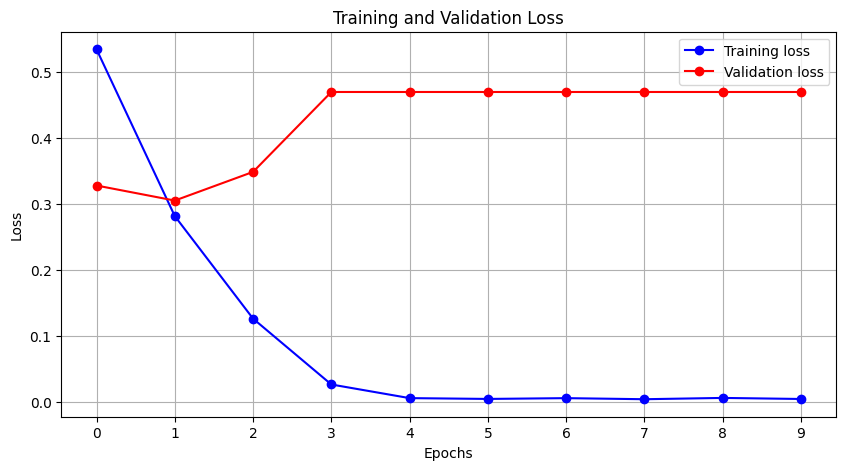

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss_values, 'b-o', label='Training loss')
plt.plot(validation_loss_values, 'r-o', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.xticks(range(0, len(train_loss_values)))
plt.grid(True)
plt.show()



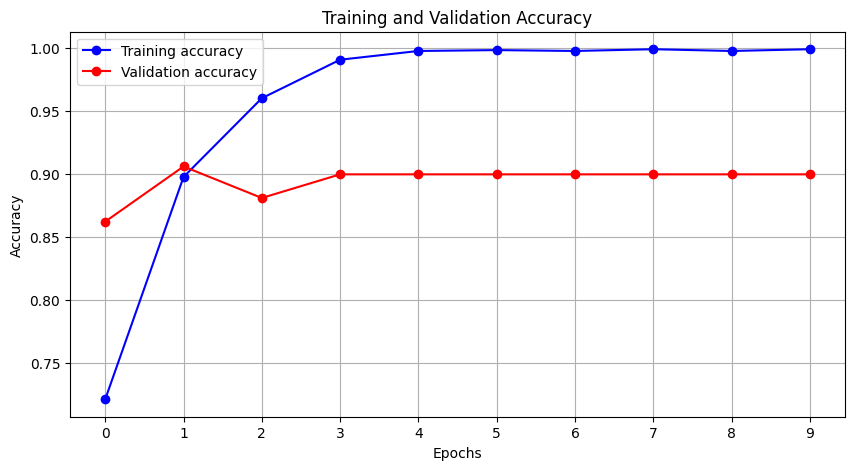

In [ ]:
# Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_accuracy_values, 'b-o', label='Training accuracy')
plt.plot(validation_accuracy_values, 'r-o', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.xticks(range(0, len(train_accuracy_values)))
plt.grid(True)
plt.show()
